In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats

In [3]:
#pip install --upgrade openpyxl


In [4]:
#'/Users/elysa/Desktop/ER Project Datasets
# Load datasets
path = '/Users/elysa/Downloads/emergency-department-volume-and-capacity-2021-2023.xlsx'
ed = pd.read_excel(path)

In [5]:

#Load and filter

columns_needed = ['oshpd_id', 'year', 'Category', 'Visits_Per_Station','HospitalOwnership', 'UrbanRuralDesi', 'TEACHINGDesignation',
    'PrimaryCareShortageArea', 'MentalHealthShortageArea'
]
ed_filtered = ed[columns_needed]

# Pivot to one column per diagnosis category
pivot_visits = ed_filtered.pivot_table(index=['oshpd_id', 'year'],columns='Category',values='Visits_Per_Station',aggfunc='mean',fill_value=0)

#Get one row per hospital/year for characteristics
hospital_attrs = ed_filtered.drop_duplicates(subset=['oshpd_id', 'year'])[['oshpd_id', 'year', 'HospitalOwnership', 'UrbanRuralDesi',
     'TEACHINGDesignation', 'PrimaryCareShortageArea', 'MentalHealthShortageArea']].set_index(['oshpd_id', 'year'])
hospital_encoded = pd.get_dummies(hospital_attrs, drop_first=False)
attribute_cols = hospital_encoded.columns.tolist() 

combined_df = hospital_encoded.join(pivot_visits)

#Correlation: hospital attributes vs diagnosis visit rates
correlation_matrix = combined_df.corr().loc[attribute_cols, pivot_visits.columns]


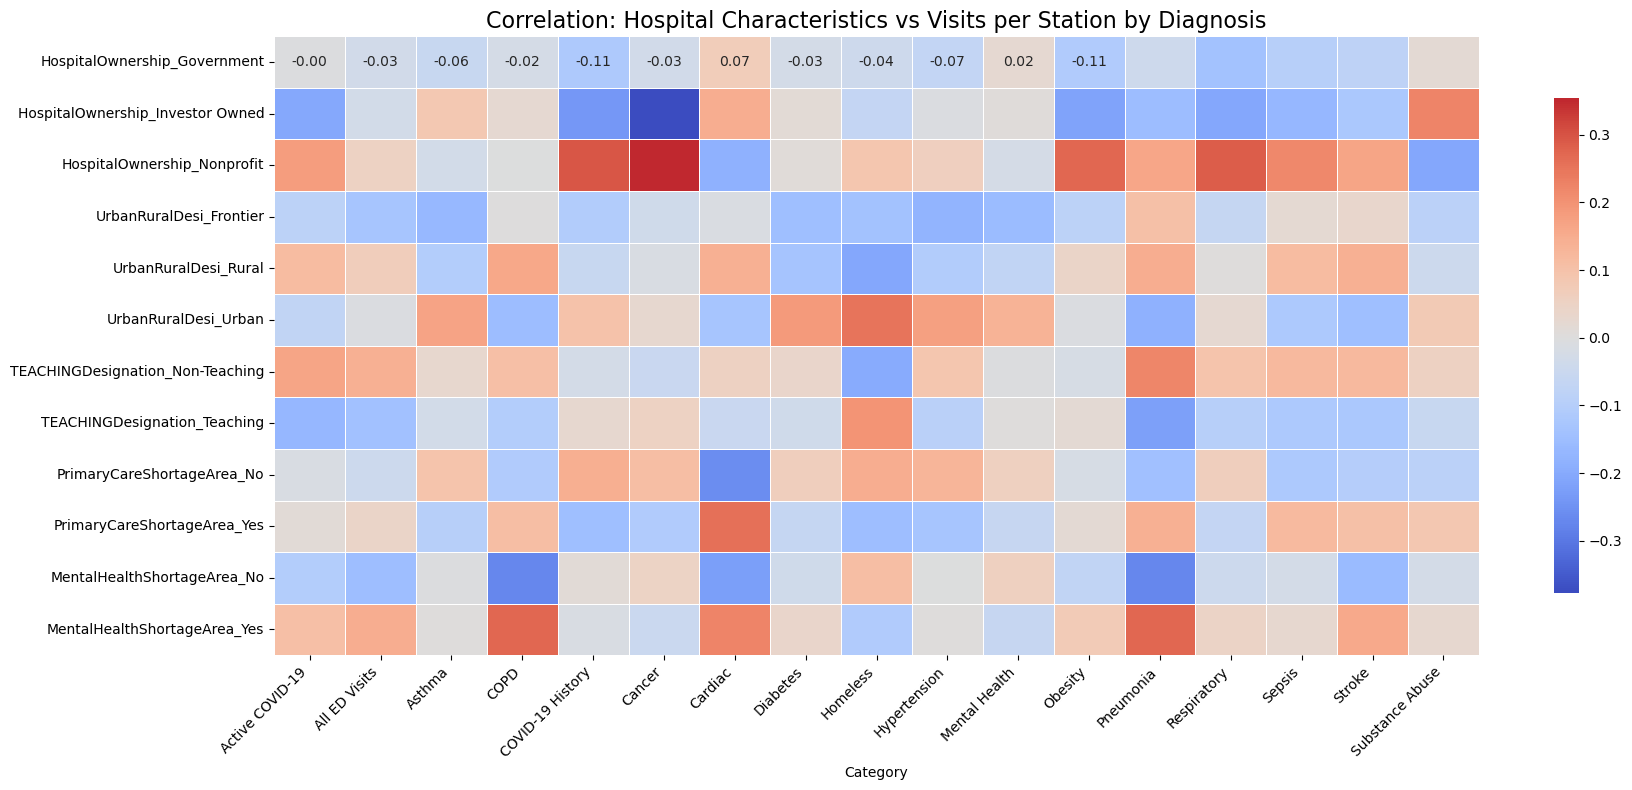

In [6]:
#Plot heatmap
plt.figure(figsize=(18, 8))
sns.heatmap(correlation_matrix,annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5, cbar_kws={"shrink": 0.8})

plt.title("Correlation: Hospital Characteristics vs Visits per Station by Diagnosis", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


/var/folders/7g/gblq5dw54b98ghbc1w_djjfm0000gn/T/ipykernel_43439/2012238720.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = (df.groupby(['Category', 'PrimaryCareShortageArea'])[value_col].agg(agg).reset_index())
/var/folders/7g/gblq5dw54b98ghbc1w_djjfm0000gn/T/ipykernel_43439/2012238720.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = (df.groupby(['Category', 'PrimaryCareShortageArea'])[value_col].agg(agg).reset_index())


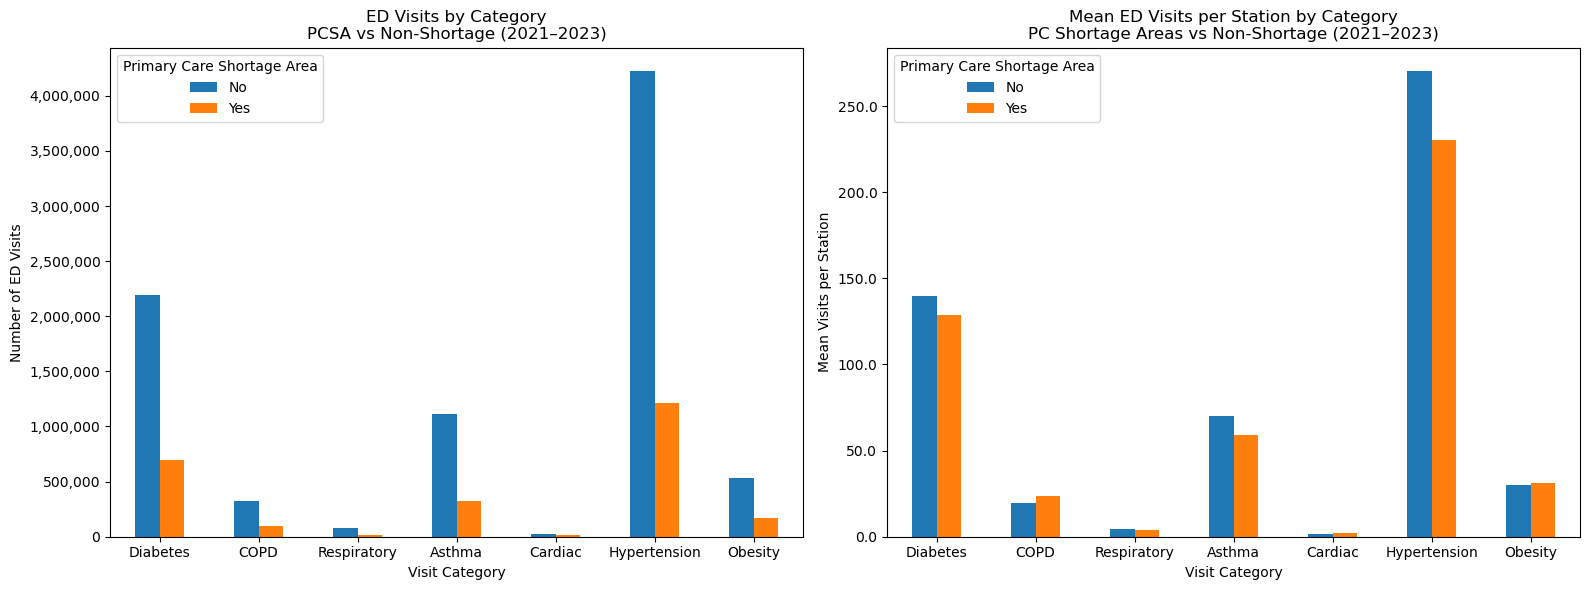

In [7]:
from matplotlib.ticker import FuncFormatter
from pandas.api.types import CategoricalDtype

chronic_categories = ['Diabetes', 'COPD', 'Respiratory', 'Asthma', 'Cardiac', 'Hypertension', 'Obesity']

# Filter enforcing consistent category order
chronic = ed[ed['Category'].isin(chronic_categories)].copy()
cat_type = CategoricalDtype(chronic_categories, ordered=True)
chronic['Category'] = chronic['Category'].astype(cat_type)

# Build pivot table for plotting
def pivot_chronic(df, value_col, agg='sum'):
    grouped = (df.groupby(['Category', 'PrimaryCareShortageArea'])[value_col].agg(agg).reset_index()) 
    pivot = (grouped.pivot(index='Category', columns='PrimaryCareShortageArea', values=value_col).reindex(chronic_categories).fillna(0))
    return pivot
    
chronic_counts = pivot_chronic(chronic, 'EDDXCount', agg='sum')
chronic_rate   = pivot_chronic(chronic, 'Visits_Per_Station', agg='mean')

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: total counts
ax0 = chronic_counts.plot(kind='bar', ax=axes[0])
ax0.set_title('ED Visits by Category\nPCSA vs Non-Shortage (2021–2023)')
ax0.set_xlabel('Visit Category')
ax0.set_ylabel('Number of ED Visits')
ax0.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
ax0.legend(title='Primary Care Shortage Area')
ax0.tick_params(axis='x', rotation=0)

# Right: mean visits per station
ax1 = chronic_rate.plot(kind='bar', ax=axes[1])
ax1.set_title('Mean ED Visits per Station by Category\nPC Shortage Areas vs Non-Shortage (2021–2023)')
ax1.set_xlabel('Visit Category')
ax1.set_ylabel('Mean Visits per Station')
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.1f}'))
ax1.legend(title='Primary Care Shortage Area')
ax1.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


In [8]:
mental_categories = ['Homeless', 'Mental Health', 'Substance Abuse']

mental = ed[ed['Category'].isin(mental_categories)].copy()
cat_type = CategoricalDtype(mental_categories, ordered=True)
mental['Category'] = mental['Category'].astype(cat_type)

def pivot_mental(df, value_col, agg='sum'):
    grouped = (df.groupby(['Category', 'MentalHealthShortageArea'])[value_col].agg(agg).reset_index())
    pivot = (grouped.pivot(index='Category', columns='MentalHealthShortageArea', values=value_col).reindex(mental_categories).fillna(0))
    return pivot


mental_counts = pivot_mental(mental, 'EDDXCount', agg='sum')
mental_rate   = pivot_mental(mental, 'Visits_Per_Station', agg='mean')


/var/folders/7g/gblq5dw54b98ghbc1w_djjfm0000gn/T/ipykernel_43439/209077943.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = (df.groupby(['Category', 'MentalHealthShortageArea'])[value_col].agg(agg).reset_index())
/var/folders/7g/gblq5dw54b98ghbc1w_djjfm0000gn/T/ipykernel_43439/209077943.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = (df.groupby(['Category', 'MentalHealthShortageArea'])[value_col].agg(agg).reset_index())


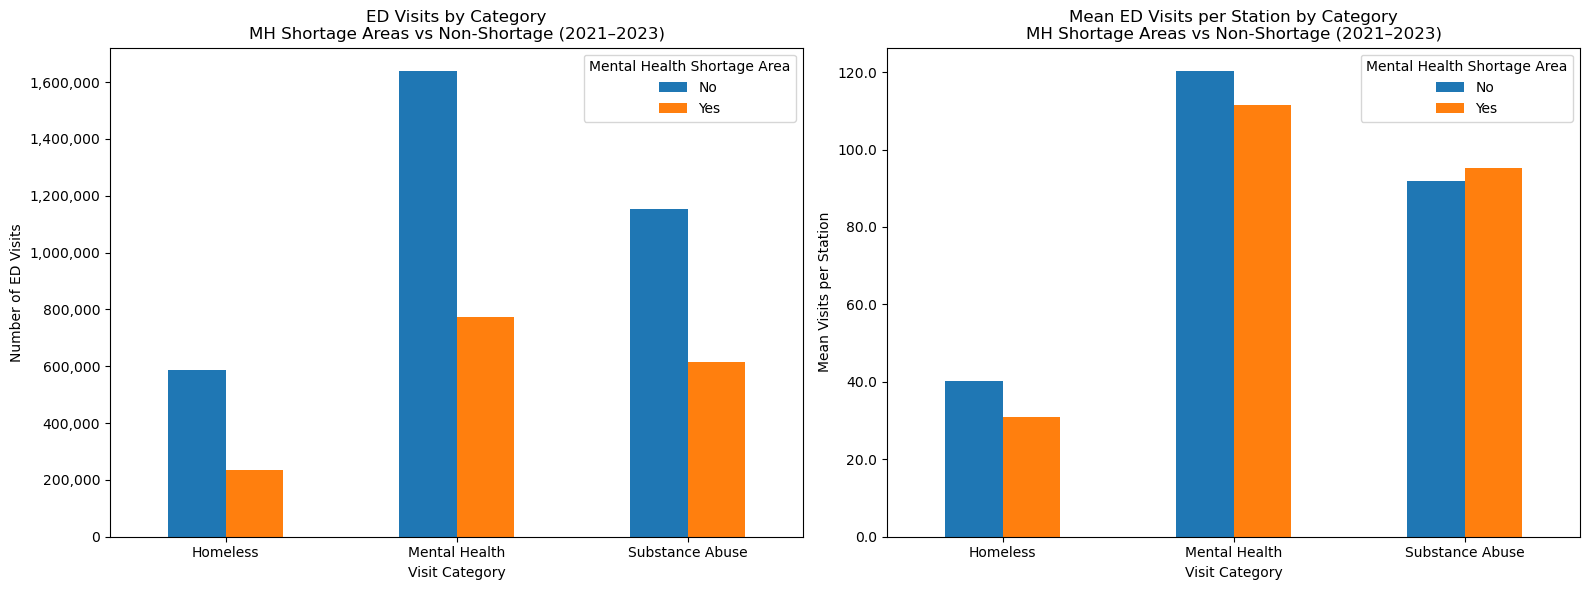

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax0 = mental_counts.plot(kind='bar', ax=axes[0])
ax0.set_title('ED Visits by Category\nMH Shortage Areas vs Non-Shortage (2021–2023)')
ax0.set_xlabel('Visit Category')
ax0.set_ylabel('Number of ED Visits')
ax0.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
ax0.legend(title='Mental Health Shortage Area')
ax0.tick_params(axis='x', rotation=0)

ax1 = mental_rate.plot(kind='bar', ax=axes[1])
ax1.set_title('Mean ED Visits per Station by Category\nMH Shortage Areas vs Non-Shortage (2021–2023)')
ax1.set_xlabel('Visit Category')
ax1.set_ylabel('Mean Visits per Station')
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.1f}'))
ax1.legend(title='Mental Health Shortage Area')
ax1.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()
